## Import necessary library

In [48]:
import os
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from util.parse_loc import parse_forecast_file

## Load The DataFrame from the models forecasted folder

In [49]:
forecast_folder = Path("forecast_price") / "LSTM"

crops = {
    "Cassava": "cassava_forecast.txt",
    "Corn": "corn_forecast.txt",
    "Green Bean": "green_bean_forecast.txt",
    "Soybean": "soybean_forecast.txt",
}

In [50]:
crop_data = {}

for crop_name, file_name in crops.items():
    file_path = os.path.join(forecast_folder, file_name)

    if os.path.exists(file_path):
        dates, prices = parse_forecast_file(file_path)
        crop_data[crop_name] = {"dates": dates, "prices": prices}
        print(f"Loaded {crop_name} data: {len(prices)} price points")
    else:
        print(f"Warning: {file_path} not found")

print(f"\nLoaded data for {len(crop_data)} crops")

crop_price_avg = {}

for crop_name, data in crop_data.items():
    dates = data["dates"]
    prices = data["prices"]

    if len(prices) > 0:
        avg_price = np.round(np.mean(prices), 2)
        crop_price_avg[crop_name] = avg_price
        print(f"{crop_name} average price: {avg_price:.2f}")
    else:
        print(f"No price data available for {crop_name}")


Loaded Cassava data: 12 price points
Loaded Corn data: 12 price points
Loaded Green Bean data: 12 price points
Loaded Soybean data: 12 price points

Loaded data for 4 crops
Cassava average price: 2.91
Corn average price: 11.22
Green Bean average price: 24.64
Soybean average price: 18.42


In [51]:
for crop_name, data in crop_data.items():
    new_data_lst = []

    for price in data["prices"]:
        if price != 0:
            new_data_lst.append(price / float(crop_price_avg[crop_name]))

    crop_data[crop_name]["prices"] = new_data_lst

In [52]:
time_grow = {"Cassava": 250, "Corn": 120, "Green Bean": 80, "Soybean": 90}
crops_yield_per_rai = {"Cassava": 3500, "Corn": 1500, "Green Bean": 245, "Soybean": 300}

## Gantt chart (With no optimization)

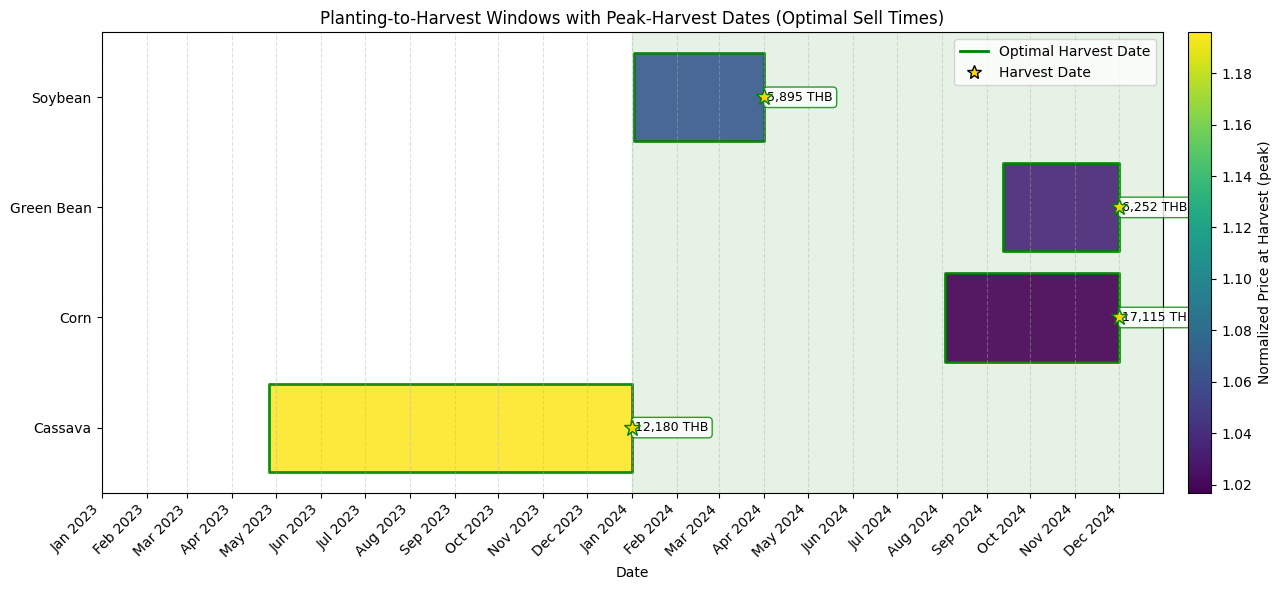

Land Utilization: 79% (463 days with crops / 585 total days)


Gantt chart shows 4 planting-to-harvest windows:
Crop         Plant Date   Harvest Date Income (THB)   
------------------------------------------------------------
Cassava      2023-04-26   2024-01-01   12,180.00
Corn         2024-08-03   2024-12-01   17,115.00
Green Bean   2024-09-12   2024-12-01   6,252.40
Soybean      2024-01-02   2024-04-01   5,895.00


In [ ]:
prepared = {}
for crop, data in crop_data.items():
    dates_raw = data["dates"]
    prices_raw = data["prices"]

    # Parse dates robustly
    dates = pd.to_datetime(pd.Series(dates_raw), errors="coerce")
    prices = pd.to_numeric(pd.Series(prices_raw), errors="coerce")
    mask = dates.notna() & prices.notna() & np.isfinite(prices.values)

    dates = dates[mask].to_list()  # python datetimes
    prices = prices[mask].astype(float).to_numpy()

    if len(dates) >= 3:
        prepared[crop] = (dates, prices)


# 2) Find the single best harvest date per crop (highest price peak)
def find_best_harvest_date(dates_py, prices_np):
    """Find the date with the highest price (best harvest time)"""
    if len(prices_np) == 0:
        return None, None

    # Find the index of the maximum price
    max_idx = np.argmax(prices_np)
    return dates_py[max_idx], float(prices_np[max_idx])


# 3) Build tasks: one bar per crop using the best harvest date
bars = []  # list of dicts: {crop, start_dt, end_dt, peak_price}
for crop, (dates_py, prices_np) in prepared.items():
    if crop not in time_grow:
        continue

    harvest_dt, peak_price = find_best_harvest_date(dates_py, prices_np)
    if harvest_dt is None:
        continue

    grow_days = int(time_grow[crop])
    start_dt = harvest_dt - timedelta(days=grow_days)

    # Calculate income for this crop
    yield_per_rai = crops_yield_per_rai[crop]
    actual_peak_price = peak_price * crop_price_avg[crop]
    rai = 1  # Assume 1 rai of land
    income = yield_per_rai * actual_peak_price * rai

    bars.append(
        {
            "crop": crop,
            "start_dt": start_dt,
            "end_dt": harvest_dt,
            "peak_price": peak_price,
            "actual_price": actual_peak_price,
            "income": income,
            "strategy": "original",  # All bars are original strategy in this version
        }
    )

if not bars:
    print("No bars to plot (check dates/prices/time_grow).")
else:
    # Compute desired x-range: start 1 year before earliest forecast date
    if prepared:
        all_first_dates = [min(v[0]) for v in prepared.values() if len(v[0])]
        all_last_dates = [max(v[0]) for v in prepared.values() if len(v[0])]
        earliest_forecast_dt = min(all_first_dates)
        latest_forecast_dt = max(all_last_dates)
        latest_bar_end = max(b["end_dt"] for b in bars) if bars else latest_forecast_dt
        x_left = earliest_forecast_dt - pd.Timedelta(days=365)
        x_right = max(latest_forecast_dt, latest_bar_end) + pd.Timedelta(days=30)
    else:
        x_left, x_right = None, None

    # 4) Plot Gantt-like chart
    fig, ax = plt.subplots(figsize=(14, 6))

    # Assign a y-position per crop (use time_grow order for consistency)
    crops_order = [c for c in time_grow.keys() if c in prepared]
    y_map = {c: j for j, c in enumerate(crops_order)}

    # Normalize peak intensities for color scaling
    all_peak_vals = np.array([b["peak_price"] for b in bars])
    vmin, vmax = (
        (float(np.min(all_peak_vals)), float(np.max(all_peak_vals)))
        if len(all_peak_vals)
        else (0.0, 1.0)
    )
    denom = (vmax - vmin) if vmax > vmin else 1.0

    # Create highlight region for the target year 2024 (same as in optimized chart)
    year_2024_start = datetime(2024, 1, 1)
    year_2024_end = datetime(2024, 12, 31)
    year_2024_start_num = mdates.date2num(year_2024_start)
    year_2024_end_num = mdates.date2num(year_2024_end)
    ax.axvspan(
        year_2024_start_num,
        year_2024_end_num,
        alpha=0.1,
        color="green",
        zorder=0,
        label="Target Year (2024)",
    )

    for b in bars:
        y = y_map[b["crop"]]
        start_num = mdates.date2num(b["start_dt"])  # matplotlib date number
        end_num = mdates.date2num(b["end_dt"])  # matplotlib date number
        width = max(end_num - start_num, 0.5)  # ensure visible width

        intensity = (b["peak_price"] - vmin) / denom
        color = plt.cm.viridis(intensity)

        # Add edge colors to match optimized chart style
        edge_color = "green"  # All are "original" strategy in this chart
        edge_style = "-"

        # Draw bar with enhanced styling
        ax.broken_barh(
            [(start_num, width)],
            (y - 0.4, 0.8),
            facecolors=color,
            edgecolors=edge_color,
            linestyles=edge_style,
            linewidth=2,
            alpha=0.9,
        )

        # Mark the harvest (peak) date with a star
        ax.plot(
            end_num,
            y,
            marker="*",
            color="gold",
            markersize=12,
            markeredgecolor=edge_color,
            zorder=5,
        )

        # Add income label to match optimized chart
        ax.text(
            end_num + 2,
            y,
            f"{b['income']:,.0f} THB",
            va="center",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=edge_color, alpha=0.8),
        )

    # Enhanced axis and labeling
    ax.set_yticks(list(y_map.values()), list(y_map.keys()))
    ax.set_xlabel("Date")
    ax.set_title(
        "Planting-to-Harvest Windows with Peak-Harvest Dates (Optimal Sell Times)"
    )

    # Apply extended x-limits if available
    if x_left is not None and x_right is not None:
        ax.set_xlim(x_left, x_right)

    # Enhanced date formatting to match optimized chart
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.xticks(rotation=45, ha="right")

    # Add legend for clarity
    from matplotlib.lines import Line2D

    legend_elements = [
        Line2D(
            [0],
            [0],
            color=edge_color,
            lw=2,
            linestyle="-",
            label="Optimal Harvest Date",
        ),
        Line2D(
            [0],
            [0],
            marker="*",
            color="gold",
            markeredgecolor="black",
            linestyle="None",
            markersize=10,
            label="Harvest Date",
        ),
    ]

    ax.legend(handles=legend_elements, loc="upper right")

    # Colorbar for peak price intensity
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("Normalized Price at Harvest (peak)")

    # Enhanced grid
    ax.grid(True, linestyle="--", alpha=0.4, axis="x")
    plt.tight_layout()
    plt.show()

    # Calculate land utilization (% of year used for crops)
    earliest_start = min(b["start_dt"] for b in bars)
    latest_end = max(b["end_dt"] for b in bars)
    total_days = (latest_end - earliest_start).days

    # Calculate how many days had at least one crop growing
    dates = []
    for b in bars:
        # Add all days from start to end for this crop
        current = b["start_dt"]
        while current <= b["end_dt"]:
            dates.append(current.date())
            current += timedelta(days=1)

    # Count unique dates
    unique_dates = len(set(dates))
    utilization = int(100 * unique_dates / total_days)

    print(
        f"Land Utilization: {utilization}% ({unique_dates} days with crops / {total_days} total days)\n"
    )

    # Print summary with enhanced details
    print(f"\nGantt chart shows {len(bars)} planting-to-harvest windows:")
    print(f"{'Crop':<12} {'Plant Date':<12} {'Harvest Date':<12} {'Income (THB)':<15}")
    print("-" * 60)
    for b in bars:
        print(
            f"{b['crop']:<12} {b['start_dt'].strftime('%Y-%m-%d'):<12} {b['end_dt'].strftime('%Y-%m-%d'):<12} {b['income']:,.2f}"
        )

# Convert normalized prices back to actual prices using the original averages
harvest_incomes = {}


In [54]:
crop_candidates = []
for crop, data in harvest_incomes.items():
    crop_candidates.append(
        {
            "crop": crop,
            "income": data["income"],
            "duration": time_grow[crop],
            "harvest_date": data["harvest_date"],
            "peak_price": data["peak_price"],
        }
    )


crop_candidates.sort(key=lambda x: x["income"], reverse=True)
year_2024_start = datetime(2024, 1, 1)
year_2024_end = datetime(2024, 12, 31)

## Optimization Function: Non-overlapping schedule in 2024 (Scheduling/Knapsack)

### Find Price at Date

In [55]:
def find_price_at_date(crop, date):
    """
    Find the price for a crop at a specific date by interpolating between available dates
    """
    # Get dates and prices for this crop
    if crop not in crop_data:
        return None

    dates = pd.to_datetime(crop_data[crop]["dates"])
    prices = crop_data[crop]["prices"]

    # If the date is before the first forecast date or after the last, return the first/last price
    if date < min(dates):
        return prices[0]
    if date > max(dates):
        return prices[-1]

    # Find the closest dates before and after the target date
    # Convert to pandas datetime for easier manipulation
    date_pd = pd.Timestamp(date)

    # Find position where our date would fit in the sorted dates
    for i in range(len(dates) - 1):
        if dates[i] <= date_pd <= dates[i + 1]:
            # Interpolate between the two closest dates
            # Calculate days from the first date to the target date
            days_diff = (date_pd - dates[i]).days
            total_days = (dates[i + 1] - dates[i]).days
            if total_days == 0:  # Same date
                return prices[i]
            # Linear interpolation
            price_diff = prices[i + 1] - prices[i]
            interpolated_price = prices[i] + (price_diff * days_diff / total_days)
            return interpolated_price

    # If we're here, we couldn't find a proper interval (should not happen given our range check above)
    return None

### Calculate Crop Income

In [56]:
def calculate_crop_income(crop, harvest_date, normalized_price=None):
    """
    Calculate income for a crop based on its harvest date
    """
    if normalized_price is None:
        # Find the price at harvest date
        normalized_price = find_price_at_date(crop, harvest_date)
        if normalized_price is None:
            return 0.0  # Cannot calculate income

    # Convert normalized price to actual price
    actual_price = normalized_price * crop_price_avg[crop]

    # Calculate income: yield_per_rai * price * rai
    yield_per_rai = crops_yield_per_rai[crop]
    rai = 1  # Assume 1 rai of land
    income = yield_per_rai * actual_price * rai

    return income

### Find non-overlapping Schedule

In [57]:
def find_non_overlapping_schedule(
    candidates, target_year_start=year_2024_start, target_year_end=year_2024_end
):
    """
    Find a non-overlapping schedule for crops, prioritizing by income
    and trying to fit harvests into target year (2024)
    """
    # Start with an empty schedule
    schedule = []
    used_crops = set()

    # Track intervals that are already booked
    intervals = []

    # Strategies count for debugging
    strategy_count = {
        "original": 0,
        "shifted_within_year": 0,
        "previous_year": 0,
        "excluded": 0,
    }

    # Step 3: Try to schedule each crop, starting with most profitable
    for cand in candidates:
        crop = cand["crop"]
        if crop in used_crops:
            continue

        # Original dates from the peak price analysis
        original_harvest = cand["harvest_date"]
        duration = cand["duration"]
        original_plant = original_harvest - timedelta(days=duration)

        # First strategy: Try original dates
        conflict = False
        for start, end in intervals:
            # Check if this interval overlaps with any existing interval
            if not (original_plant >= end or original_harvest <= start):
                conflict = True
                break

        if not conflict:
            # Original dates work! Add to schedule
            intervals.append((original_plant, original_harvest))
            schedule.append(
                {
                    "crop": crop,
                    "start_dt": original_plant,
                    "end_dt": original_harvest,
                    "income": cand["income"],
                    "peak_price": cand["peak_price"],
                    "strategy": "original",
                }
            )
            used_crops.add(crop)
            strategy_count["original"] += 1
            continue

        # Strategy 2: Try to shift within target year while avoiding conflicts
        # Find gaps between scheduled intervals where this crop could fit
        all_within_year = False

        # Find available gaps
        gaps = []
        # Add the gap from start of year to first interval
        if intervals:
            intervals.sort(key=lambda x: x[0])  # Sort by start date
            if intervals[0][0] > target_year_start:
                gaps.append((target_year_start, intervals[0][0]))

            # Add gaps between intervals
            for i in range(len(intervals) - 1):
                if intervals[i + 1][0] - intervals[i][1] >= timedelta(days=duration):
                    gaps.append((intervals[i][1], intervals[i + 1][0]))

            # Add gap from last interval to end of year
            if intervals[-1][1] < target_year_end:
                gaps.append((intervals[-1][1], target_year_end))
        else:
            # If no intervals yet, the entire year is available
            gaps.append((target_year_start, target_year_end))

        # Try to place in gaps, preferring gaps that allow harvest in 2024
        placed = False
        for g_start, g_end in gaps:
            # Try to fit the crop in this gap
            if g_end - g_start >= timedelta(days=duration):
                # Can fit! Try to position for harvest in 2024 if possible
                end_candidate = min(g_end, target_year_end)
                start_candidate = end_candidate - timedelta(days=duration)

                # Check if start date is after gap start
                if start_candidate >= g_start:
                    # Calculate new income based on the shifted harvest date
                    new_harvest_date = end_candidate
                    # Get normalized price at the new harvest date
                    normalized_price = find_price_at_date(crop, new_harvest_date)
                    # If we can't find a price, use the original as fallback
                    if normalized_price is None:
                        normalized_price = cand["peak_price"]
                    # Calculate new income with new price
                    new_income = calculate_crop_income(
                        crop, new_harvest_date, normalized_price
                    )
                    # Convert normalized price to actual price
                    actual_price = normalized_price * crop_price_avg[crop]

                    schedule.append(
                        {
                            "crop": crop,
                            "start_dt": start_candidate,
                            "end_dt": end_candidate,
                            "income": new_income,  # Updated income calculation
                            "peak_price": actual_price
                            / crop_price_avg[crop],  # New normalized price
                            "strategy": "shifted_within_year",
                        }
                    )
                    intervals.append((start_candidate, end_candidate))
                    used_crops.add(crop)
                    strategy_count["shifted_within_year"] += 1
                    placed = True
                    break

        if placed:
            continue

        # Strategy 3: Allow planting in previous year for long-duration crops
        # Try the largest gap, but allow start_dt to be before 2024
        if gaps:
            # Find the largest gap
            largest_gap = max(gaps, key=lambda x: x[1] - x[0])
            g_start, g_end = largest_gap

            # Try to place with harvest in 2024
            end_candidate = min(g_end, target_year_end)
            start_candidate = end_candidate - timedelta(days=duration)

            # Even if start is before 2024, add if harvest is in 2024
            if end_candidate <= target_year_end and end_candidate >= target_year_start:
                # Calculate new income based on the shifted harvest date
                new_harvest_date = end_candidate
                # Get normalized price at the new harvest date
                normalized_price = find_price_at_date(crop, new_harvest_date)
                # If we can't find a price, use the original as fallback
                if normalized_price is None:
                    normalized_price = cand["peak_price"]
                # Calculate new income with new price
                new_income = calculate_crop_income(
                    crop, new_harvest_date, normalized_price
                )
                # Convert normalized price to actual price
                actual_price = normalized_price * crop_price_avg[crop]

                schedule.append(
                    {
                        "crop": crop,
                        "start_dt": start_candidate,
                        "end_dt": end_candidate,
                        "income": new_income,  # Updated income calculation
                        "peak_price": actual_price
                        / crop_price_avg[crop],  # New normalized price
                        "strategy": "previous_year",
                    }
                )
                intervals.append((start_candidate, end_candidate))
                used_crops.add(crop)
                strategy_count["previous_year"] += 1
                continue

        # If we get here, we couldn't schedule this crop
        strategy_count["excluded"] += 1

    return schedule, strategy_count

## Run the optimization Algorithm

In [58]:
optimized_schedule, strategy_stats = find_non_overlapping_schedule(crop_candidates)

# Check what crops were included/excluded
all_crops = set([c["crop"] for c in crop_candidates])
scheduled_crops = set([s["crop"] for s in optimized_schedule])
excluded_crops = all_crops - scheduled_crops

# Calculate total income with optimized schedule
total_optimized_income = sum(item["income"] for item in optimized_schedule)
total_original_income = sum(c["income"] for c in crop_candidates)

## Gantt chart (With Crop Schedule Optimization System)

In [59]:
# Step 5: Visualize the optimized schedule in a Gantt chart
optimized_bars = optimized_schedule

if optimized_bars:
    # Set the x-axis range from start of earliest planting to end of latest harvest
    schedule_span_start = min(b["start_dt"] for b in optimized_bars) - timedelta(
        days=30
    )
    schedule_span_end = max(b["end_dt"] for b in optimized_bars) + timedelta(days=30)

    # Create the Gantt chart
    fig, ax = plt.subplots(figsize=(14, 6))

    # Assign a y-position per crop (alphabetical for consistency)
    crops_order = sorted(list(set([b["crop"] for b in optimized_bars])))
    y_map = {c: j for j, c in enumerate(crops_order)}

    # Normalize peak intensities for color scaling
    all_peak_vals = np.array([float(b["peak_price"]) for b in optimized_bars])
    vmin, vmax = (
        (float(np.min(all_peak_vals)), float(np.max(all_peak_vals)))
        if len(all_peak_vals)
        else (0.0, 1.0)
    )
    denom = (vmax - vmin) if vmax > vmin else 1.0

    # Color coding for different strategies
    strategy_colors = {
        "original": "green",
        "shifted_within_year": "blue",
        "previous_year": "purple",
    }

    # Draw a semi-transparent overlay for 2024
    year_2024_start_num = mdates.date2num(year_2024_start)
    year_2024_end_num = mdates.date2num(year_2024_end)
    ax.axvspan(
        year_2024_start_num,
        year_2024_end_num,
        alpha=0.1,
        color="green",
        zorder=0,
        label="Target Year (2024)",
    )

    for b in optimized_bars:
        y = y_map[b["crop"]]
        start_num = mdates.date2num(b["start_dt"])
        end_num = mdates.date2num(b["end_dt"])
        width = max(end_num - start_num, 0.5)  # ensure visible width

        # Edge color based on strategy
        edge_color = strategy_colors.get(b["strategy"], "black")
        edge_style = "-" if b["strategy"] == "original" else "--"

        # Color by price (higher prices = warmer colors)
        intensity = (float(b["peak_price"]) - vmin) / denom if denom else 0.5
        color = plt.cm.viridis(intensity)

        # Draw bar
        ax.broken_barh(
            [(start_num, width)],
            (y - 0.4, 0.8),
            facecolors=color,
            edgecolors=edge_color,
            linestyles=edge_style,
            linewidth=2,
            alpha=0.9,
        )

        # Mark the harvest date with a star
        ax.plot(
            end_num,
            y,
            marker="*",
            color="gold",
            markersize=12,
            markeredgecolor=edge_color,
            zorder=5,
        )

        # Add crop name and income label
        ax.text(
            end_num + 2,
            y,
            f"{b['income']:,.0f} THB",
            va="center",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=edge_color, alpha=0.8),
        )

    # Configure the chart
    ax.set_yticks(list(y_map.values()), list(y_map.keys()))
    ax.set_xlabel("Date")
    ax.set_title("Optimized Non-Overlapping Planting-to-Harvest Schedule")

    # Set the x-axis range
    ax.set_xlim(schedule_span_start, schedule_span_end)

    # Format x-axis dates
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.xticks(rotation=45, ha="right")

    # Add target year highlighting label to legend
    handles, labels = ax.get_legend_handles_labels()

    # Create legend entries for strategies
    from matplotlib.lines import Line2D

    legend_elements = [
        Line2D(
            [0],
            [0],
            color=strategy_colors["original"],
            lw=2,
            linestyle="-",
            label="Original Peak Date",
        ),
        Line2D(
            [0],
            [0],
            color=strategy_colors["shifted_within_year"],
            lw=2,
            linestyle="--",
            label="Shifted within 2024",
        ),
        Line2D(
            [0],
            [0],
            color=strategy_colors["previous_year"],
            lw=2,
            linestyle="--",
            label="Planted in Previous Year",
        ),
    ]

    ax.legend(handles=legend_elements, loc="upper right")

    # Add grid and show
    ax.grid(True, linestyle="--", alpha=0.4, axis="x")
    plt.tight_layout()
    plt.show()

    # Calculate land utilization (% of year used for crops)
    earliest_start = min(b["start_dt"] for b in optimized_bars)
    latest_end = max(b["end_dt"] for b in optimized_bars)
    total_days = (latest_end - earliest_start).days

    # Calculate how many days had at least one crop growing
    dates = []
    for b in optimized_bars:
        # Add all days from start to end for this crop
        current = b["start_dt"]
        while current <= b["end_dt"]:
            dates.append(current.date())
            current += timedelta(days=1)

    # Count unique dates
    unique_dates = len(set(dates))
    utilization = int(100 * unique_dates / total_days)

    print(
        f"Land Utilization: {utilization}% ({unique_dates} days with crops / {total_days} total days)\n"
    )
else:
    print("No crops were scheduled. Check the constraints and data.")


# Report results
print("Crop Schedule Optimization Results")
print("=" * 50)
print(f"Total crops: {len(crop_candidates)}")
print(f"Scheduled crops: {len(optimized_schedule)}")
print(
    f"Excluded crops: {len(excluded_crops)} {list(excluded_crops) if excluded_crops else ''}"
)
print("\nScheduling strategies used:")
for strategy, count in strategy_stats.items():
    print(f"  {strategy}: {count} crops")

print(f"\nTotal income before optimization: {total_original_income:,.2f} THB")
print(f"Total income after optimization: {total_optimized_income:,.2f} THB")
print(
    f"Optimization impact: {100 * total_optimized_income / total_original_income:.1f}% of original income"
)

print("\nOptimized schedule details:")
print(
    f"{'Crop':<12} {'Plant Date':<12} {'Harvest Date':<12} {'Strategy':<20} {'Income (THB)':<15}"
)
print("-" * 70)
for item in sorted(optimized_schedule, key=lambda x: x["end_dt"]):
    print(
        f"{item['crop']:<12} {item['start_dt'].strftime('%Y-%m-%d'):<12} {item['end_dt'].strftime('%Y-%m-%d'):<12} {item['strategy']:<20} {item['income']:,.2f}"
    )


No crops were scheduled. Check the constraints and data.
Crop Schedule Optimization Results
Total crops: 0
Scheduled crops: 0
Excluded crops: 0 

Scheduling strategies used:
  original: 0 crops
  shifted_within_year: 0 crops
  previous_year: 0 crops
  excluded: 0 crops

Total income before optimization: 0.00 THB
Total income after optimization: 0.00 THB


ZeroDivisionError: division by zero